# Error Diagnostic Pipeline

This notebook represents a pipeline that takes a `predictions.csv` supplied by ML engineers, and a reference training dataset.

It performs a K-Nearest Neighbors (KNN) analysis on embedding vectors for every False Positive and False Negative, and categorically dissects **why** the model made an error using 6 heuristical strategies (Angles).

## Input
- `predictions.csv`
- `Sarcasm_Headlines_Dataset.json`

## Output
- `error_root_causes.csv`: Contains the mandatory and optional columns requested by the user, and attaches the diagnostic root issue.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [ ]:
# Configuration
PREDICTIONS_CSV = Path("deBERTa/results/20260414/predictions.csv") # your final predictions
DATASET_JSON = Path("deBERTa/Sarcasm_Headlines_Dataset.json") # this should be your base dataset
EMBEDDING_MODEL = Path("deBERTa/results/20260414/best_checkpoints/checkpoint-8540").resolve() # where you save your NN model
BATCH_SIZE = 64
K_NEIGHBORS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")
TOKENIZER_MODEL = EMBEDDING_MODEL



Using device: cpu


In [ ]:
# 1. Load the Predictions (Provided by ML Engineers)
df_preds = pd.read_csv(PREDICTIONS_CSV)
print(f"Loaded {len(df_preds)} total predictions.")

# 2. Filter to only the errors
errors_df = df_preds[df_preds['correct'] == 0].reset_index(drop=True)
print(f"Found {len(errors_df)} errors to analyze.")

Loaded 1825 total predictions.
Found 119 errors to analyze.


In [ ]:
# 3. Load the Training/Reference Dataset (For KNN Knowledge Base)
df_ref = pd.read_json(DATASET_JSON, lines=True)
print(f"Loaded {len(df_ref)} reference samples from training data.")

Loaded 27142 reference samples from training data.


In [ ]:
# 4. Compute Embeddings

print(f"Loading model: {EMBEDDING_MODEL}...")
if not EMBEDDING_MODEL.exists():
    raise FileNotFoundError(f"Local checkpoint not found: {EMBEDDING_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(str(TOKENIZER_MODEL), local_files_only=True)
try:
    from peft import PeftConfig, PeftModel
    peft_config = PeftConfig.from_pretrained(str(EMBEDDING_MODEL))
    base = AutoModel.from_pretrained(peft_config.base_model_name_or_path).to(DEVICE)
    model = PeftModel.from_pretrained(base, str(EMBEDDING_MODEL)).to(DEVICE)
    model = model.merge_and_unload()
except Exception as e:
    print(f"Not a PEFT model or loading failed: {e}. Falling back.")
    model = AutoModel.from_pretrained(str(EMBEDDING_MODEL), local_files_only=True).to(DEVICE)

def encode_texts(texts):
    vectors = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i : i + BATCH_SIZE]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
            outputs = model(**encoded)
            # mean pooling
            mask = encoded["attention_mask"].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
            summed = (outputs.last_hidden_state * mask).sum(dim=1)
            denom = torch.clamp(mask.sum(dim=1), min=1e-9)
            pooled = summed / denom
            normalized = torch.nn.functional.normalize(pooled, p=2, dim=1)
            vectors.append(normalized.cpu().numpy())
    import numpy as np
    return np.vstack(vectors)

print("Encoding reference dataset (this may take a minute)...")
ref_embeddings = encode_texts(df_ref['headline'].astype(str).tolist())
print("Encoding error samples...")
error_embeddings = encode_texts(errors_df['headline'].astype(str).tolist())


Loading model: D:\Lectures\Assignments\CS4248\CS4248-Group-18-Project\deBERTa\results\20260410_182345\checkpoints\checkpoint-5085...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: D:\Lectures\Assignments\CS4248\CS4248-Group-18-Project\deBERTa\results\20260410_182345\checkpoints\checkpoint-5085
Key                                    | Status     |  | 
---------------------------------------+------------+--+-
incongruity.proj.{0, 2}.bias           | UNEXPECTED |  | 
incongruity.bilinear.bias              | UNEXPECTED |  | 
sentiment_head.{0, 2}.weight           | UNEXPECTED |  | 
classifier.{0, 2, 5}.bias              | UNEXPECTED |  | 
emotion_lstm.lstm.bias_hh_l0_reverse   | UNEXPECTED |  | 
emotion_lstm.proj.{0, 2}.bias          | UNEXPECTED |  | 
sentiment_head.{0, 2}.bias             | UNEXPECTED |  | 
incongruity.proj.{0, 2}.weight         | UNEXPECTED |  | 
attn_pool.query                        | UNEXPECTED |  | 
emotion_lstm.lstm.bias_hh_l0           | UNEXPECTED |  | 
classifier.{0, 2, 5}.weight            | UNEXPECTED |  | 
incongruity.bilinear.weight            | UNEXPECTED |  | 
attn_pool.key_proj.weight              |

Encoding reference dataset (this may take a minute)...
Encoding error samples...


In [ ]:
# 5. KNN Search
print("Fitting KNN on reference data...")
knn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="cosine")
knn.fit(ref_embeddings)
distances, indices = knn.kneighbors(error_embeddings)

Fitting KNN on reference data...


In [ ]:
# 6. Apply Heuristic Angles to categorize errors
records = []
for i, row in errors_df.iterrows():
    # Gather neighbors
    neighbor_idx = indices[i]
    neighbor_dist = distances[i]
    neighbors = df_ref.iloc[neighbor_idx].copy()
    
    # Calculate KNN stats
    sarcastic_ratio = (neighbors['is_sarcastic'] == 1).mean()
    closest_dist = neighbor_dist[0]
    closest_label = int(neighbors.iloc[0]['is_sarcastic'])
    
    # Flags & Metas
    is_fp = row['error_type'] == 'false_positive'
    is_fn = row['error_type'] == 'false_negative'
    actual_label = row['true_label']
    pred_label = row['pred_label']
    conf = row['confidence']
    token_len = row['token_len_approx'] if 'token_len_approx' in row else len(str(row['headline']).split())
    has_exclamation = row['exclamation'] if 'exclamation' in row else ('!' in str(row['headline']))
    has_question = row['question'] if 'question' in row else ('?' in str(row['headline']))
    has_full_stop = '.' in str(row['headline'])
    
    # --- The 6 Angles ---
    
    # Angle 2: Outlier (No data close)
    is_outlier = closest_dist > 0.15
    
    # Angle 1: Label Conflict (Data close but opposite actual label, typically boundary fuzzy issue)
    is_conflict = (closest_dist <= 0.15) and (closest_label != actual_label)
    
    # Angle 3: Systematic Bias (Data close, neighbor has the predicted/wrong label, high conf)
    is_systematic_bias = (closest_dist <= 0.15) and (closest_label == pred_label) and (conf > 0.90)
    
    # Angle 4: Low-Signal Ambiguity (Low conf + short text)
    is_ambiguous = (conf < 0.60) and (token_len < 6)
    
    # Angle 5: Syntactic Spurious Correlation (Punctuation relied upon falsely)
    is_syntactic_bias = is_fp and (has_exclamation or has_question) and closest_dist > 0.10
    
    # Angle 6: Mixed Neighborhood
    is_mixed = 0.3 <= sarcastic_ratio <= 0.7
    
    # Priority Resolution (some conditions overlap, we assign the most distinct one)
    if is_outlier: issue_cat = "Angle 2: Outlier / Zero-Shot Zone"
    elif is_ambiguous: issue_cat = "Angle 4: Low-Signal Ambiguity (Too short/vague)"
    elif is_systematic_bias: issue_cat = "Angle 3: Systematic Bias / Learned Spurious Rule"
    elif is_syntactic_bias: issue_cat = "Angle 5: Punctuation Spurious Correlation"
    elif is_conflict: issue_cat = "Angle 1: Label Conflict (Fuzzy Boundary)"
    elif is_mixed: issue_cat = "Angle 6: Mixed Neighborhood (Tangled Region)"
    else: issue_cat = "Uncategorized Error"
    
    # Formatting mandatory and optional columns for output CSV
    records.append({
        # Mandatory
        "Index": row.name, # Original index or localized error index
        "Article_Link": row['article_link'],
        "Headline": row['headline'],
        "Dataset": "Validation/Test" if 'source' not in row else row['source'],
        "Probability of non sarcastic": row.get('prob_non_sarcastic', 1 - row.get('prob_sarcastic', 0)),
        "Probability of sarcastic": row.get('prob_sarcastic', 0),
        "Confidence": conf,
        "Predicted is sarcastic": pred_label,
        "Actual label": actual_label,
        "Is correct?": row['correct'],
        "False +ve": 1 if is_fp else 0,
        "False -ve": 1 if is_fn else 0,
        
        # Optional
        "Text length": len(str(row['headline'])),
        "approximate token length": token_len,
        "is exclamation?": 1 if has_exclamation else 0,
        "is question?": 1 if has_question else 0,
        "is full stop?": 1 if has_full_stop else 0,
        
        # Diagnostics
        "Distance to closest neighbor": closest_dist,
        "Closest neighbor label": closest_label,
        "Neighbor sarcastic ratio": sarcastic_ratio,
        "Identified Category": issue_cat
    })

results_df = pd.DataFrame(records)
results_df.to_csv("error_root_causes.csv", index=False)
print("Pipeline complete. Output saved to 'error_root_causes.csv'")
print(f"Total Errors Processed: {len(results_df)}")

Pipeline complete. Output saved to 'error_root_causes.csv'
Total Errors Processed: 119


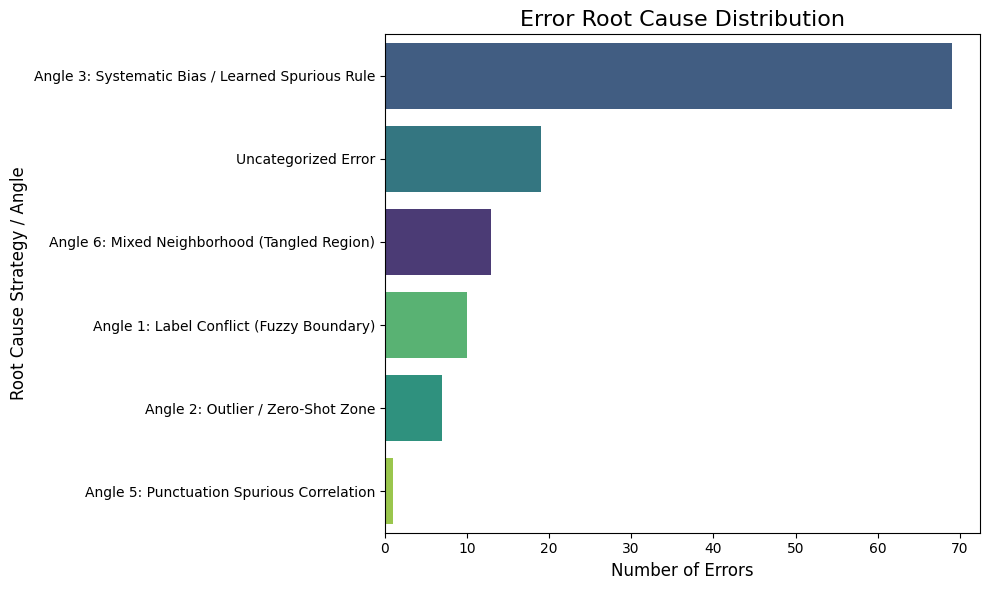

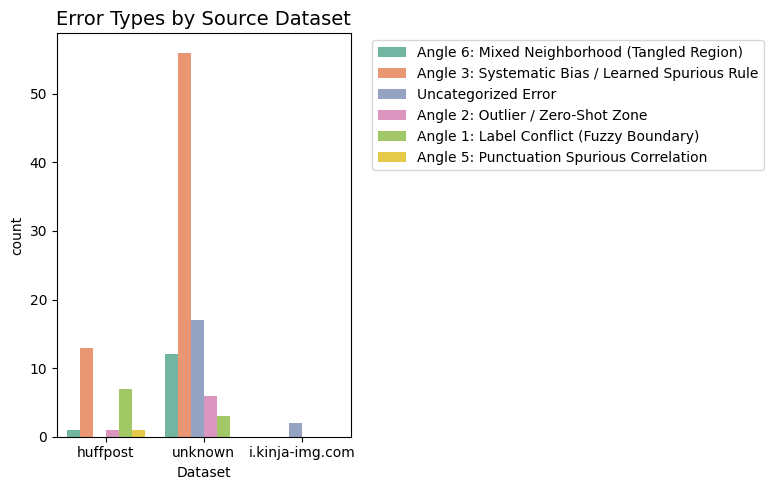

In [ ]:
# 7. Visualizations
plt.figure(figsize=(10, 6))
sns.countplot(
    data=results_df, 
    y="Identified Category", 
    order=results_df["Identified Category"].value_counts().index, 
    palette="viridis",
    hue="Identified Category",
    legend=False
)
plt.title("Error Root Cause Distribution", fontsize=16)
plt.xlabel("Number of Errors", fontsize=12)
plt.ylabel("Root Cause Strategy / Angle", fontsize=12)
plt.tight_layout()
plt.show()

# Visualize error rate by Dataset source (if present)
if 'Dataset' in results_df.columns and results_df['Dataset'].nunique() > 1:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=results_df, 
        x="Dataset", 
        hue="Identified Category", 
        palette="Set2"
    )
    plt.title("Error Types by Source Dataset", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# Let's peek at a few of the errors categorized as 'Label Conflict (Fuzzy Boundary)'
if "Angle 1: Label Conflict (Fuzzy Boundary)" in results_df["Identified Category"].values:
    display(results_df[results_df["Identified Category"] == "Angle 1: Label Conflict (Fuzzy Boundary)"][["Headline", "Actual label", "Distance to closest neighbor"]].head(5))

# And peeking into Outliers
if "Angle 2: Outlier / Zero-Shot Zone" in results_df["Identified Category"].values:
    display(results_df[results_df["Identified Category"] == "Angle 2: Outlier / Zero-Shot Zone"][["Headline", "Actual label", "Distance to closest neighbor"]].head(5))

,Headline,Actual label,Distance to closest neighbor
4,goldman's asset management approached as possi...,0,0.077451
9,"job growth remains sluggish, or rather, akin t...",1,0.132885
18,"outlasting dynasties, now emerging from soot",0,0.139545
54,i'm with stupid: watch where you're aiming tha...,0,0.123460
57,nation’s top teachers confront betsy devos in ...,0,0.061399


,Headline,Actual label,Distance to closest neighbor
3,man’s wife dies of cancer just like in the movies,1,0.161254
20,"man, that mourning really did the trick!",1,0.180060
22,massachusetts mayors battle melatonin brownie,1,0.189916
35,"my god, what passes for crunch-tastic these days",1,0.162923
103,trump disapproval rating reaches all-time none...,1,0.172017


Computing t-SNE to project 768-D embeddings to 2D (this may take a minute due to non-linear mapping)...


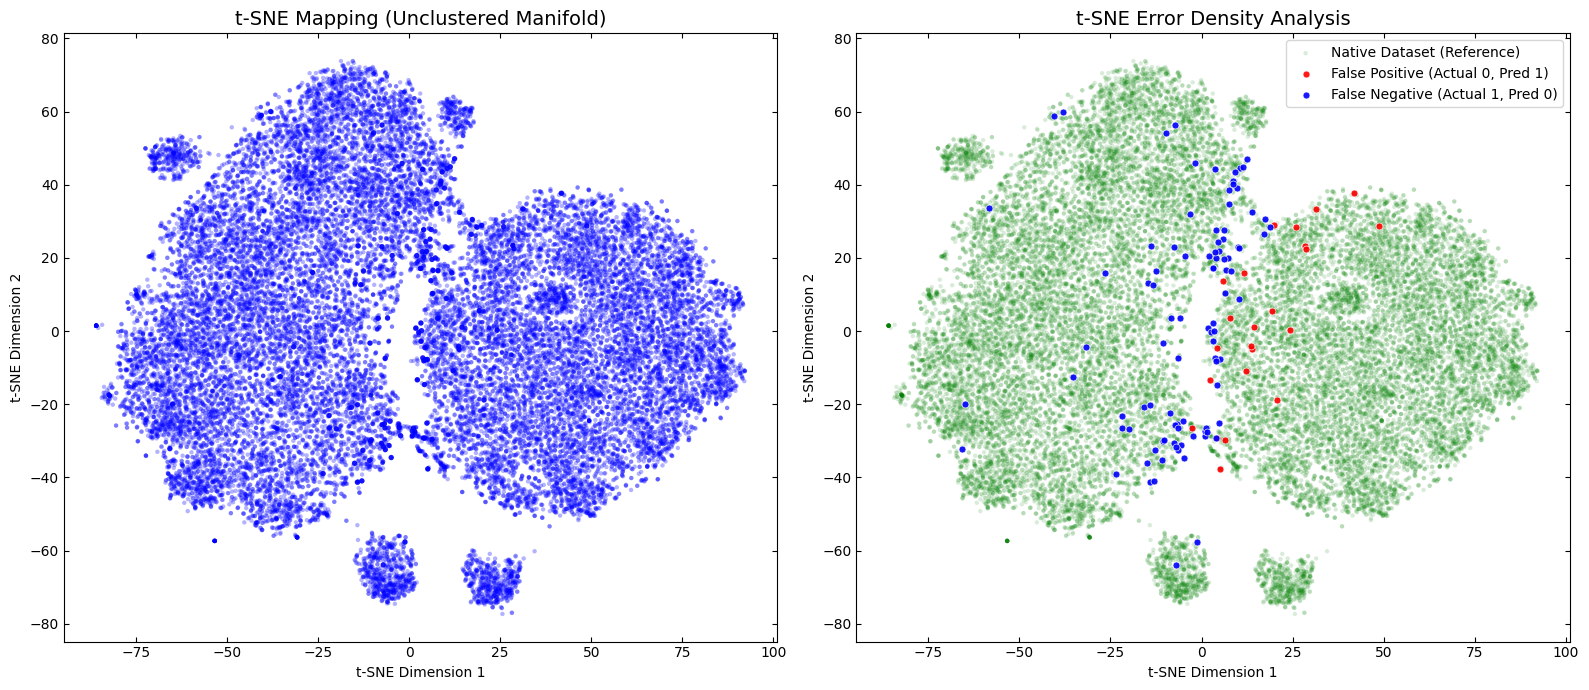

t-SNE Side-by-side graph rendered.


In [ ]:
# 8. Visual Isolation Graph (Side-by-Side View using t-SNE)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

print("Computing t-SNE to project 768-D embeddings to 2D (this may take a minute due to non-linear mapping)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
all_embeddings = np.vstack([ref_embeddings, error_embeddings])

# t-SNE does not have a separate fit/transform, it calculates all points simultaneously
all_2d = tsne.fit_transform(all_embeddings)

# Split back into reference and errors
n_ref = len(ref_embeddings)
ref_2d = all_2d[:n_ref]
error_2d = all_2d[n_ref:]

# Subsetting errors
is_fp = errors_df['error_type'] == 'false_positive'
is_fn = errors_df['error_type'] == 'false_negative'

fp_2d = error_2d[is_fp]
fn_2d = error_2d[is_fn]

# Create 1x2 Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left Plot: Original unclustered data ---
axes[0].set_title("t-SNE Mapping (Unclustered Manifold)", fontsize=14)
axes[0].scatter(ref_2d[:, 0], ref_2d[:, 1], c='blue', alpha=0.3, s=10, edgecolors='none')
axes[0].scatter(error_2d[:, 0], error_2d[:, 1], c='blue', alpha=0.9, s=15, edgecolors='none')
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].tick_params(direction='in', top=True, right=True)

# --- Right Plot: Clustered/Categorized data ---
axes[1].set_title("t-SNE Error Density Analysis", fontsize=14)
# Plot the native reference knowledge base in Green
axes[1].scatter(ref_2d[:, 0], ref_2d[:, 1], c='green', alpha=0.15, s=10, edgecolors='none', label='Native Dataset (Reference)')

# Plot False Positives in Red
axes[1].scatter(fp_2d[:, 0], fp_2d[:, 1], c='red', alpha=0.9, s=25, label='False Positive (Actual 0, Pred 1)', edgecolors='white', linewidth=0.5)

# Plot False Negatives in Blue
axes[1].scatter(fn_2d[:, 0], fn_2d[:, 1], c='blue', alpha=0.9, s=25, label='False Negative (Actual 1, Pred 0)', edgecolors='white', linewidth=0.5)

axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print("t-SNE Side-by-side graph rendered.")


Fitting KMeans (k=8) on 119 error embeddings ...

  MESO-LEVEL CLUSTER REPORT  (K=8)

──────────────────────────────────────────────────────────────────────
  C0: versace, sawadee thai, sawadee, thai a380, thai
  Size: 16  │  FP: 15  │  FN: 1
──────────────────────────────────────────────────────────────────────
  [1] goldman's asset management approached as possible candidate for bank of england governor
  [2] jetblue event raises question of unstable approach to hiring
  [3] stage door: 'one hand clapping, clinton the musical'
  [4] dead toddler's father pleads insanity to corpse abuse

──────────────────────────────────────────────────────────────────────
  C1: million, addresses, bush addresses, bush, addresses million
  Size: 4  │  FP: 0  │  FN: 4
──────────────────────────────────────────────────────────────────────
  [1] drought reveals 113 million-year-old dinosaur tracks in texas
  [2] bush addresses 8.2 million unemployed: 'get a job'
  [3] man’s wife dies of cancer just like

C:\Users\ervin\AppData\Local\Temp\ipykernel_14500\691265234.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("tab10", N_CLUSTERS)


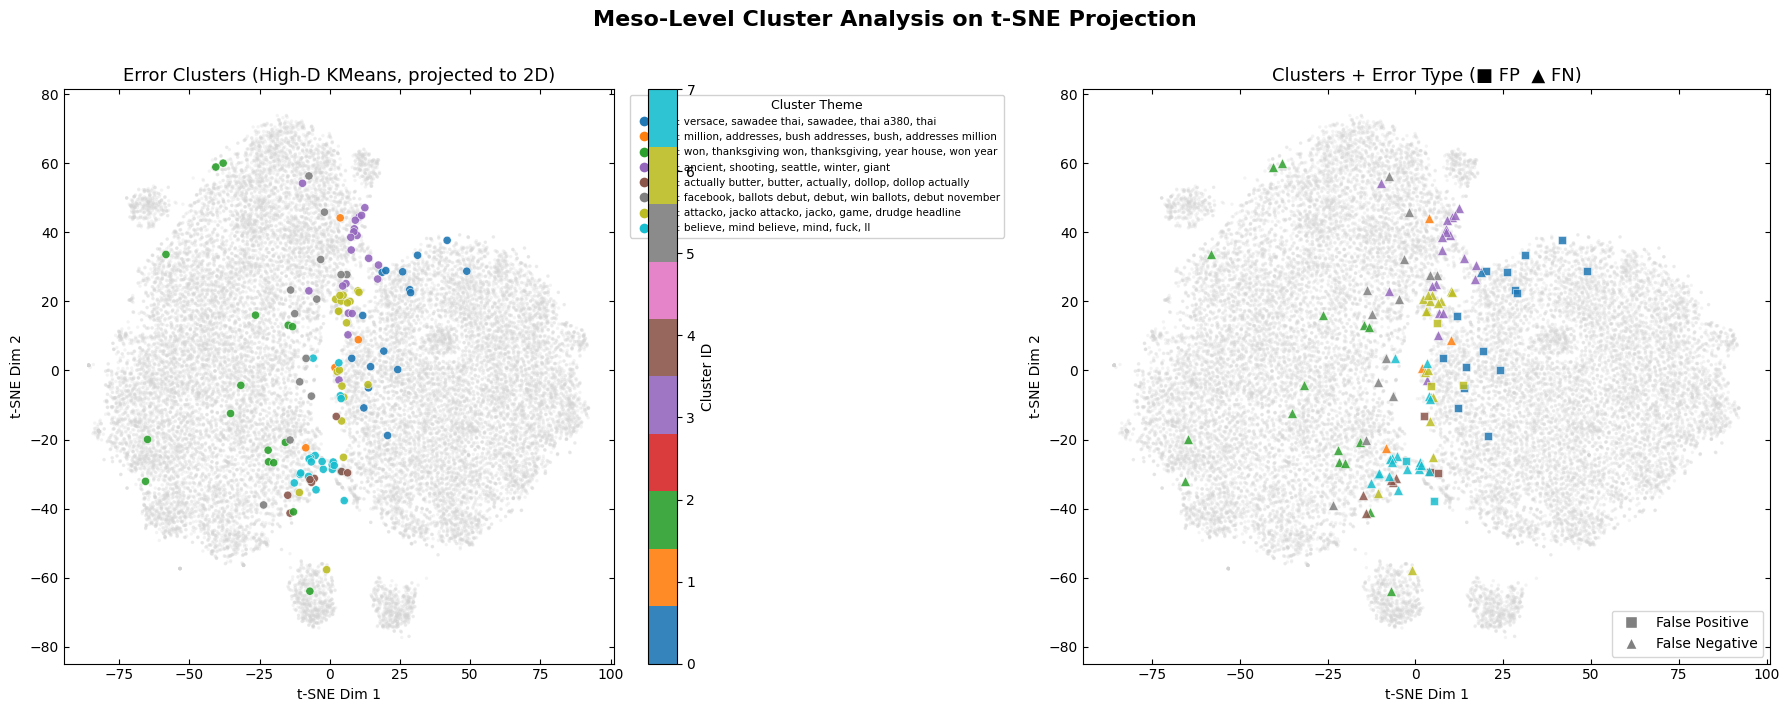

Meso-level cluster analysis complete.


In [ ]:
# ─────────────────────────────────────────────────
# 9. Meso-Level Cluster Analysis
#    Cluster the 768-D error embeddings with KMeans,
#    auto-name each cluster with TF-IDF keywords, and
#    visualise on the existing t-SNE 2D projection.
# ─────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Parameters ────────────────────────────────────
N_CLUSTERS = 8          # ← tune this easily
N_KEYWORDS = 5          # top TF-IDF keywords per cluster
N_SAMPLES  = 4          # sample headlines to print per cluster
RANDOM_STATE = 42

# ── 1. Cluster the high-dimensional error embeddings ──────────────────────
print(f"Fitting KMeans (k={N_CLUSTERS}) on {len(error_embeddings)} error embeddings ...")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")
cluster_labels = kmeans.fit_predict(error_embeddings)     # shape: (n_errors,)

# Attach cluster IDs back to errors_df (non-destructive copy)
errors_clustered = errors_df.copy()
errors_clustered["cluster_id"] = cluster_labels

# ── 2. Auto-name clusters with TF-IDF ─────────────────────────────────────
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
tfidf.fit(errors_clustered["headline"].astype(str))
feature_names = np.array(tfidf.get_feature_names_out())

cluster_themes = {}
for cid in range(N_CLUSTERS):
    mask = errors_clustered["cluster_id"] == cid
    cluster_headlines = errors_clustered.loc[mask, "headline"].astype(str).tolist()
    if len(cluster_headlines) == 0:
        cluster_themes[cid] = f"Cluster {cid} (empty)"
        continue
    tfidf_matrix = tfidf.transform(cluster_headlines)
    mean_scores   = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_idx       = mean_scores.argsort()[::-1][:N_KEYWORDS]
    keywords      = ", ".join(feature_names[top_idx])
    cluster_themes[cid] = f"C{cid}: {keywords}"

errors_clustered["cluster_theme"] = errors_clustered["cluster_id"].map(cluster_themes)

# ── 3. Textual per-cluster report ─────────────────────────────────────────
print("\n" + "="*70)
print(f"  MESO-LEVEL CLUSTER REPORT  (K={N_CLUSTERS})")
print("="*70)

for cid in range(N_CLUSTERS):
    mask = errors_clustered["cluster_id"] == cid
    sub  = errors_clustered[mask]
    n_fp = (sub["error_type"] == "false_positive").sum()
    n_fn = (sub["error_type"] == "false_negative").sum()

    print(f"\n{'─'*70}")
    print(f"  {cluster_themes[cid]}")
    print(f"  Size: {len(sub)}  │  FP: {n_fp}  │  FN: {n_fn}")
    print(f"{'─'*70}")
    samples = sub["headline"].sample(min(N_SAMPLES, len(sub)), random_state=RANDOM_STATE)
    for i, headline in enumerate(samples, 1):
        print(f"  [{i}] {headline}")

print("\n" + "="*70)

# ── 4. Export cluster column to error_root_causes.csv ─────────────────────
try:
    root_causes_df = pd.read_csv("error_root_causes.csv")
    # errors_df rows are in the same order as error_root_causes, safe to assign
    if len(root_causes_df) == len(errors_clustered):
        root_causes_df["Cluster ID"]    = errors_clustered["cluster_id"].values
        root_causes_df["Cluster Theme"] = errors_clustered["cluster_theme"].values
        root_causes_df.to_csv("error_root_causes.csv", index=False)
        print("✓  Cluster columns written to error_root_causes.csv")
    else:
        print(f"⚠  Row count mismatch ({len(root_causes_df)} vs {len(errors_clustered)}). Skipping CSV export.")
except FileNotFoundError:
    print("⚠  error_root_causes.csv not found — skipping CSV export.")

# ── 5. t-SNE scatter coloured by cluster ─────────────────────────────────
cmap   = cm.get_cmap("tab10", N_CLUSTERS)
colors = [cmap(c) for c in cluster_labels]

is_fp_mask = errors_clustered["error_type"] == "false_positive"
is_fn_mask = errors_clustered["error_type"] == "false_negative"

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Meso-Level Cluster Analysis on t-SNE Projection", fontsize=16, fontweight="bold", y=1.01)

# ── Left: colour by cluster (all errors) ──────────────────────────────────
ax = axes[0]
ax.set_title("Error Clusters (High-D KMeans, projected to 2D)", fontsize=13)
ax.scatter(ref_2d[:, 0], ref_2d[:, 1], c="lightgray", s=6, alpha=0.25, edgecolors="none", label="Reference data")
scatter = ax.scatter(error_2d[:, 0], error_2d[:, 1], c=cluster_labels,
                     cmap="tab10", vmin=0, vmax=N_CLUSTERS-1,
                     s=35, alpha=0.9, edgecolors="white", linewidth=0.4)
plt.colorbar(scatter, ax=ax, label="Cluster ID", ticks=range(N_CLUSTERS))
ax.set_xlabel("t-SNE Dim 1"); ax.set_ylabel("t-SNE Dim 2")
ax.tick_params(direction="in", top=True, right=True)

# Custom legend for cluster themes
handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=cluster_themes[cid],
               markerfacecolor=cmap(cid), markersize=8)
    for cid in range(N_CLUSTERS)
]
ax.legend(handles=handles, title="Cluster Theme", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize=7.5, title_fontsize=9, framealpha=0.9)

# ── Right: cluster + FP/FN shape coding ───────────────────────────────────
ax2 = axes[1]
ax2.set_title("Clusters + Error Type (■ FP  ▲ FN)", fontsize=13)
ax2.scatter(ref_2d[:, 0], ref_2d[:, 1], c="lightgray", s=6, alpha=0.25, edgecolors="none")

# FP: squares; FN: triangles
for cid in range(N_CLUSTERS):
    c_mask = cluster_labels == cid
    fp_c   = c_mask & is_fp_mask.values
    fn_c   = c_mask & is_fn_mask.values
    if fp_c.any():
        ax2.scatter(error_2d[fp_c, 0], error_2d[fp_c, 1],
                    color=cmap(cid), marker="s", s=40, alpha=0.85,
                    edgecolors="white", linewidth=0.4)
    if fn_c.any():
        ax2.scatter(error_2d[fn_c, 0], error_2d[fn_c, 1],
                    color=cmap(cid), marker="^", s=50, alpha=0.85,
                    edgecolors="white", linewidth=0.4)

ax2.set_xlabel("t-SNE Dim 1"); ax2.set_ylabel("t-SNE Dim 2")
ax2.tick_params(direction="in", top=True, right=True)

# Legend: shapes only
fp_patch = plt.Line2D([0],[0], marker="s", color="w", label="False Positive", markerfacecolor="gray", markersize=9)
fn_patch = plt.Line2D([0],[0], marker="^", color="w", label="False Negative", markerfacecolor="gray", markersize=9)
ax2.legend(handles=[fp_patch, fn_patch], loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()
print("Meso-level cluster analysis complete.")


# Top Word Features for True Positives and True Negatives
Analyzing 'words and whatnot' to discover what common features appear in correctly predicted samples.

Total True Positives: 517


C:\Users\ervin\AppData\Local\Temp\ipykernel_14500\4216742004.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


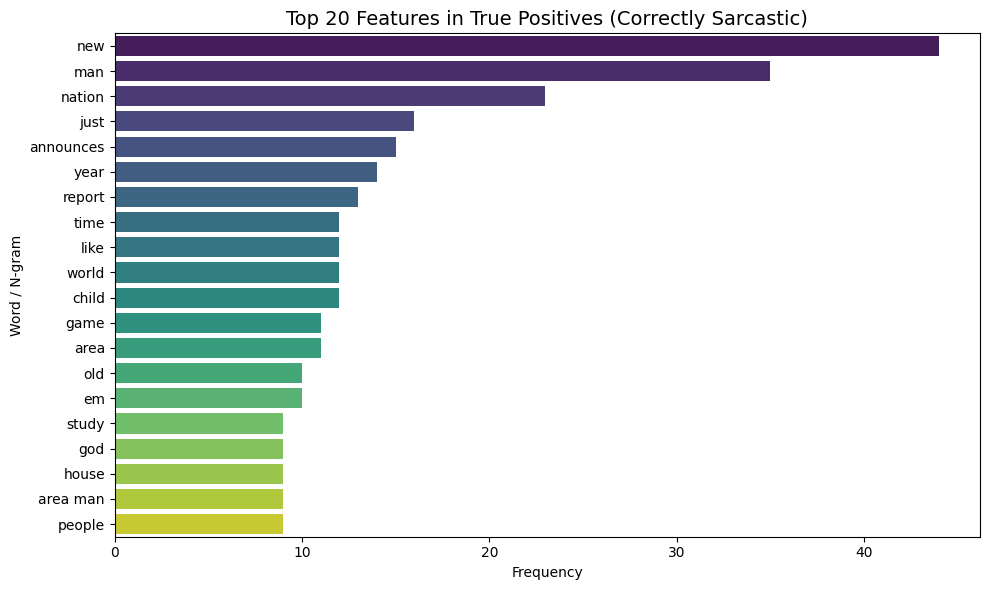

Total True Negatives: 1189


C:\Users\ervin\AppData\Local\Temp\ipykernel_14500\4216742004.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


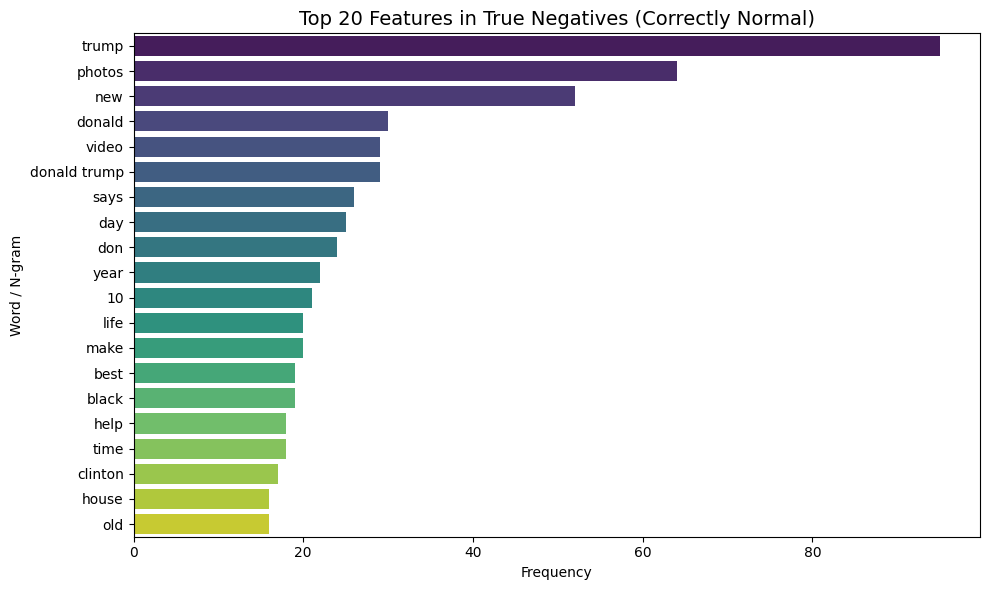

In [ ]:
# Filter true positives and true negatives
tp_df = df_preds[(df_preds['true_label'] == 1) & (df_preds['pred_label'] == 1)]
tn_df = df_preds[(df_preds['true_label'] == 0) & (df_preds['pred_label'] == 0)]

from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_n_words(corpus, title, n=20):
    # Use bigrams as well to catch 'area man' etc if applicable
    vec = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=2000).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Sort by frequency
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]
    
    words = [w[0] for w in words_freq]
    counts = [w[1] for w in words_freq]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts, y=words, palette='viridis')
    plt.title(title, fontsize=14)
    plt.xlabel('Frequency')
    plt.ylabel('Word / N-gram')
    plt.tight_layout()
    plt.show()

print(f"Total True Positives: {len(tp_df)}")
plot_top_n_words(tp_df['headline'].dropna().astype(str), 'Top 20 Features in True Positives (Correctly Sarcastic)')

print(f"Total True Negatives: {len(tn_df)}")
plot_top_n_words(tn_df['headline'].dropna().astype(str), 'Top 20 Features in True Negatives (Correctly Normal)')


C:\Users\ervin\AppData\Local\Temp\ipykernel_14500\4216742004.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


Total False Positives: 23


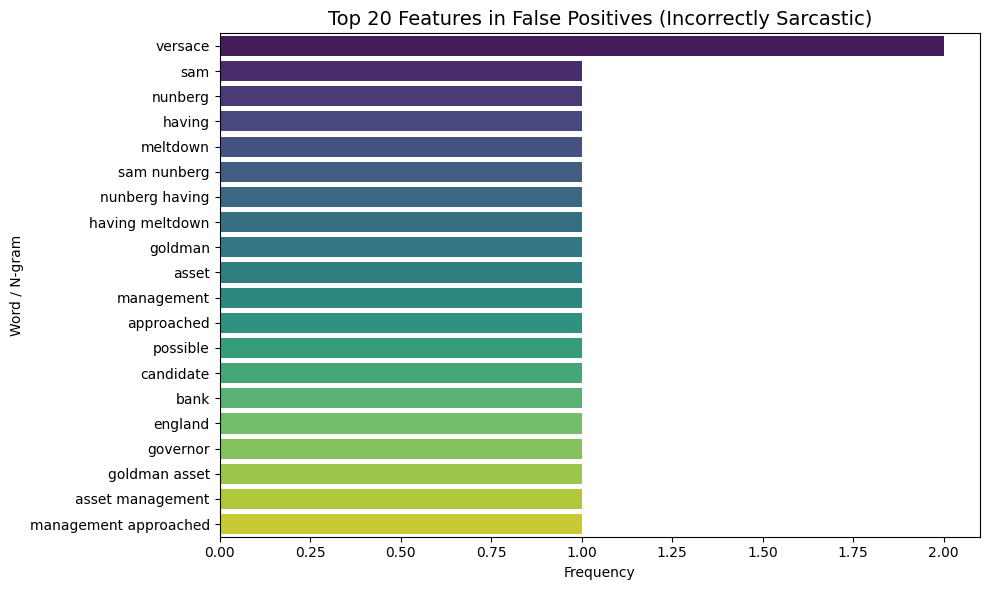

Total False Negatives: 96


C:\Users\ervin\AppData\Local\Temp\ipykernel_14500\4216742004.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


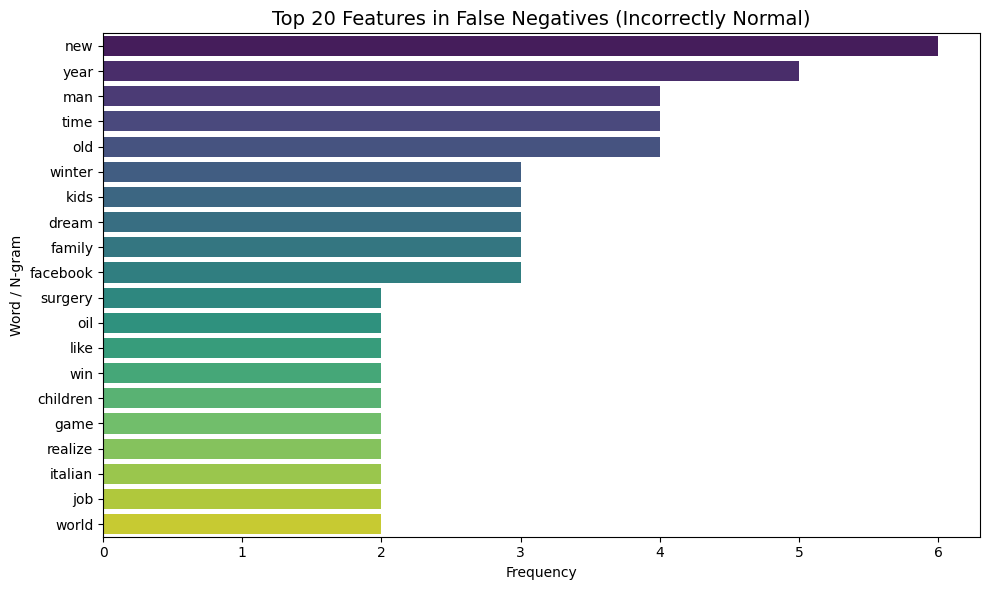

In [ ]:
# Filter false positives and false negatives
fp_df = df_preds[(df_preds['true_label'] == 0) & (df_preds['pred_label'] == 1)]
fn_df = df_preds[(df_preds['true_label'] == 1) & (df_preds['pred_label'] == 0)]

print(f"Total False Positives: {len(fp_df)}")
plot_top_n_words(fp_df['headline'].dropna().astype(str), 'Top 20 Features in False Positives (Incorrectly Sarcastic)')

print(f"Total False Negatives: {len(fn_df)}")
plot_top_n_words(fn_df['headline'].dropna().astype(str), 'Top 20 Features in False Negatives (Incorrectly Normal)')